# 🌊 Flood Mapping in Central Luzon using Sentinel Data
# Disaster Risk Reduction (DRR) Case Study

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/flood-mapping-class/blob/main/notebooks/templates/flood_mapping_workshop_colab.ipynb)

### 📋 Table of Contents
1. [Introduction](#introduction)
2. [Environment Setup](#setup)
3. [Downloading from Copernicus](#gee-auth)
4. [AI/Machine Learning Techniques for Flood Detection](#study-area)


<a name="introduction"></a>


## 1. Introduction



This notebook demonstrates flood mapping in the **Pampanga River Basin, Central Luzon, Philippines** using Sentinel satellite data simulation. We'll analyze flood events from:
- **Typhoon Ulysses (Vamco)** - November 2020
- **Typhoon Karding (Noru)** - September 2022

### 🎯 Learning Objectives:
- Understand SAR-based flood detection principles
- Apply threshold-based flood detection algorithms
- Create interactive flood extent maps
- Analyze flood statistics

### 🛰️ Why Sentinel-1 for Flood Mapping?
- **All-weather capability**: Penetrates clouds and rain
- **Day/night operation**: Not dependent on sunlight
- **Water sensitivity**: Water appears dark in SAR images
- **Regular revisit**: 6-12 day repeat cycle

### 📍 Study Area: Pampanga River Basin
- **Coverage**: ~10,540 km²
- **Population**: >6 million people
- **Provinces**: Nueva Ecija, Pampanga, Bulacan, Tarlac
- **Main hazards**: Typhoons, monsoon flooding


## 2. Enviroment set-p

In [13]:
# Install required packages for Google Colab
!pip install earthengine-api geemap folium geopandas rasterio -q

# Import all libraries

import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import folium
from IPython.display import display, Image
import json
import os
import warnings
warnings.filterwarnings('ignore')


<a name="setup"></a>
## 3. Downloading from Copernicus

### 📥 Downloading Sentinel-1 Data from Copernicus Open Access Hub

We'll download real Sentinel-1 data for the Pampanga River Basin floods from the official Copernicus portal.

### Steps:
1. **Register** at https://dataspace.copernicus.eu/
2. **Search** for Sentinel-1 data for our typhoon events
3. **Download** the data
4. **Load** into the notebook

In [25]:
import requests
import os
from datetime import datetime

os.makedirs('data/sentinel1_subset', exist_ok=True)

print("🎯 DOWNLOAD ONLY BOUNDING BOX - NOT FULL TILE")
print("=" * 60)

# Method 1: Using Sentinel Hub Process API (Best for subsets)
def download_bbox_subset_sentinelhub(bbox, start_date, end_date, username, password):
    """Download only the bounding box area using Sentinel Hub"""

    # First get access token
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

    token_data = {
        'grant_type': 'password',
        'username': username,
        'password': password,
        'client_id': 'cdse-public'
    }

    token_response = requests.post(token_url, data=token_data)
    access_token = token_response.json()['access_token']

    # Sentinel Hub Process API endpoint
    process_url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    # Request ONLY the bounding box area
    request_body = {
        "input": {
            "bounds": {
                "bbox": bbox,  # [120.4, 14.8, 121.2, 15.6]
                "properties": {
                    "crs": "http://www.opengis.net/def/crs/EPSG/0/4326"
                }
            },
            "data": [{
                "dataFilter": {
                    "timeRange": {
                        "from": f"{start_date}T00:00:00Z",
                        "to": f"{end_date}T23:59:59Z"
                    }
                },
                "type": "sentinel-1-grd",
                "processing": {
                    "backCoeff": "GAMMA0_TERRAIN",
                    "orthorectify": True
                }
            }]
        },
        "output": {
            "width": 1024,  # Adjust resolution as needed
            "height": 1024,
            "responses": [{
                "identifier": "default",
                "format": {
                    "type": "image/tiff"
                }
            }]
        },
        "evalscript": """
        //VERSION=3
        function setup() {
            return {
                input: ["VH", "VV"],
                output: {
                    bands: 2,
                    sampleType: "FLOAT32"
                }
            };
        }

        function evaluatePixel(samples) {
            return [samples.VH, samples.VV];
        }
        """
    }

    headers = {
        'Authorization': f'Bearer {access_token}',
        'Content-Type': 'application/json'
    }

    print(f"📥 Downloading ONLY bounding box: {bbox}")
    print("   File size will be ~10-50 MB instead of 1-4 GB!")

    response = requests.post(process_url, json=request_body, headers=headers)

    if response.status_code == 200:
        filename = f"data/sentinel1_subset/pampanga_subset_{start_date}.tif"
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"✅ Downloaded subset: {filename} ({len(response.content)/1024/1024:.1f} MB)")
        return filename
    else:
        print(f"❌ Error: {response.status_code}")
        return None

# Method 2: Download with GDAL Virtual File System (for specific area)
def download_bbox_using_gdal():
    """Alternative method using GDAL to download subset"""

    print("\n📦 Alternative: Use GDAL to download subset")
    print("Run in terminal/command line:")

    # Example GDAL command to download only bbox
    gdal_command = """
gdal_translate \
  -projwin 120.4 15.6 121.2 14.8 \
  -projwin_srs EPSG:4326 \
  -of GTiff \
  /vsicurl/https://dataspace.copernicus.eu/path/to/sentinel1.tif \
  pampanga_subset.tif
"""
    print(gdal_command)

# Method 3: After downloading full tile, extract subset
def extract_subset_from_full_tile(full_tile_path, bbox):
    """Extract bounding box from already downloaded full tile"""

    import rasterio
    from rasterio.windows import from_bounds

    west, south, east, north = bbox

    with rasterio.open(full_tile_path) as src:
        # Get window for bounding box
        window = from_bounds(west, south, east, north, src.transform)

        # Read only the subset
        subset = src.read(window=window)

        # Update metadata for subset
        out_meta = src.meta.copy()
        out_meta.update({
            'height': window.height,
            'width': window.width,
            'transform': rasterio.windows.transform(window, src.transform)
        })

        # Save subset
        output_path = full_tile_path.replace('.zip', '_subset.tif')
        with rasterio.open(output_path, 'w', **out_meta) as dst:
            dst.write(subset)

        print(f"✅ Extracted subset: {output_path}")
        return output_path

# MAIN EXECUTION
print("\n🎯 DOWNLOAD OPTIONS FOR BOUNDING BOX ONLY:\n")

print("1. Use Sentinel Hub Process API (recommended)")
print("2. Download full tile then extract")
print("3. Use GDAL VSI")

choice = input("\nChoose option (1/2/3): ")

bbox = [120.4, 14.8, 121.2, 15.6]  # Pampanga Basin

if choice == "1":
    # Use Sentinel Hub for subset
    username = input("Username: ")
    password = input("Password: ")

    # Download pre and post flood subsets
    print("\n📥 Downloading pre-flood subset...")
    pre_flood = download_bbox_subset_sentinelhub(
        bbox, "2020-11-01", "2020-11-10", username, password
    )

    print("\n📥 Downloading post-flood subset...")
    post_flood = download_bbox_subset_sentinelhub(
        bbox, "2020-11-12", "2020-11-20", username, password
    )

elif choice == "2":
    # If you already downloaded full tiles
    full_tile = input("Path to full tile .zip: ")
    if os.path.exists(full_tile):
        extract_subset_from_full_tile(full_tile, bbox)
    else:
        print("❌ File not found")

else:
    download_bbox_using_gdal()

print("\n✅ Subset download complete!")
print(f"📊 Size comparison:")
print(f"   Full tile: ~1-4 GB")
print(f"   Your subset: ~10-50 MB")

🎯 DOWNLOAD ONLY BOUNDING BOX - NOT FULL TILE

🎯 DOWNLOAD OPTIONS FOR BOUNDING BOX ONLY:

1. Use Sentinel Hub Process API (recommended)
2. Download full tile then extract
3. Use GDAL VSI

Choose option (1/2/3): 1
Username: vvourlioti@neuralio.ai
Password: @EQ?SPUy4@iw

📥 Downloading pre-flood subset...
📥 Downloading ONLY bounding box: [120.4, 14.8, 121.2, 15.6]
   File size will be ~10-50 MB instead of 1-4 GB!
✅ Downloaded subset: data/sentinel1_subset/pampanga_subset_2020-11-01.tif (7.1 MB)

📥 Downloading post-flood subset...
📥 Downloading ONLY bounding box: [120.4, 14.8, 121.2, 15.6]
   File size will be ~10-50 MB instead of 1-4 GB!
✅ Downloaded subset: data/sentinel1_subset/pampanga_subset_2020-11-12.tif (7.1 MB)

✅ Subset download complete!
📊 Size comparison:
   Full tile: ~1-4 GB
   Your subset: ~10-50 MB


### List All Files in Colab

In [27]:
import os

print("📂 ALL FILES IN YOUR COLAB:")
print("=" * 50)

# List all files recursively
for root, dirs, files in os.walk('.'):
    # Skip hidden directories
    if '.' in root.split('/')[1:]:
        continue

    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)

        # Show all files with their sizes
        print(f"{filepath:<50} {size_mb:>8.1f} MB")

# Summary
print("\n" + "=" * 50)
print("📊 SUMMARY:")

# Count Sentinel files
sentinel_files = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if 'S1' in file or 'sentinel' in file.lower() or file.endswith(('.zip', '.tif', '.tiff')):
            sentinel_files.append(os.path.join(root, file))

print(f"Total Sentinel-1 files found: {len(sentinel_files)}")
if sentinel_files:
    print("\n🛰️ Sentinel-1 files:")
    for f in sentinel_files:
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"   {f} ({size_mb:.1f} MB)")

📂 ALL FILES IN YOUR COLAB:
./.config/.last_survey_prompt.yaml                      0.0 MB
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db      0.0 MB
./.config/.last_update_check.json                       0.0 MB
./.config/.last_opt_in_prompt.yaml                      0.0 MB
./.config/config_sentinel                               0.0 MB
./.config/default_configs.db                            0.0 MB
./.config/active_config                                 0.0 MB
./.config/logs/2025.06.02/13.38.36.652518.log           0.0 MB
./.config/logs/2025.06.02/13.38.27.770953.log           0.0 MB
./.config/logs/2025.06.02/13.38.06.907675.log           0.0 MB
./.config/logs/2025.06.02/13.38.37.802452.log           0.0 MB
./.config/logs/2025.06.02/13.38.47.382637.log           0.0 MB
./.config/logs/2025.06.02/13.38.46.703373.log           0.0 MB
./.config/logs/2025.06.04/13.21.20.761480.log           0.0 MB
./.config/configurations/config_default                 0.0 MB
./data

### Load Your Sentinel-1 Data

In [33]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("📥 LOADING YOUR SENTINEL-1 DATA")
print("=" * 50)

# Load the subset TIFF files (these are perfect - small and ready to use!)
pre_flood_path = './data/sentinel1_subset/pampanga_subset_2020-11-01.tif'
post_flood_path = './data/sentinel1_subset/pampanga_subset_2020-11-12.tif'

# Load pre-flood data
print("Loading pre-flood data...")
with rasterio.open(pre_flood_path) as src:
    pre_flood_data = src.read(1)  # Read first band
    transform = src.transform
    crs = src.crs

# Load post-flood data
print("Loading post-flood data...")
with rasterio.open(post_flood_path) as src:
    post_flood_data = src.read(1)

# Convert to dB (if not already)
pre_flood_db = 10 * np.log10(pre_flood_data + 1e-10)
post_flood_db = 10 * np.log10(post_flood_data + 1e-10)

# Clip to reasonable SAR values
pre_flood_db = np.clip(pre_flood_db, -30, 0)
post_flood_db = np.clip(post_flood_db, -30, 0)

print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {pre_flood_data.shape}")
print(f"   Pre-flood range: {pre_flood_db.min():.1f} to {pre_flood_db.max():.1f} dB")
print(f"   Post-flood range: {post_flood_db.min():.1f} to {post_flood_db.max():.1f} dB")

📥 LOADING YOUR SENTINEL-1 DATA
Loading pre-flood data...
Loading post-flood data...

✅ Data loaded successfully!
   Shape: (1024, 1024)
   Pre-flood range: -30.0 to 0.0 dB
   Post-flood range: -30.0 to 0.0 dB


### Visualise

In [34]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pre-flood
im1 = axes[0].imshow(pre_flood_db, cmap='gray', vmin=-25, vmax=-5)
axes[0].set_title('Pre-flood (Nov 1)', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='VH (dB)')

# Post-flood
im2 = axes[1].imshow(post_flood_db, cmap='gray', vmin=-25, vmax=-5)
axes[1].set_title('Post-flood (Nov 12)', fontsize=14)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='VH (dB)')

# Change detection
change = post_flood_db - pre_flood_db
im3 = axes[2].imshow(change, cmap='RdBu_r', vmin=-5, vmax=5)
axes[2].set_title('Change Detection', fontsize=14)
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='Change (dB)')

plt.tight_layout()
plt.show()

# Store for next steps
sentinel_data = {
    'pre_flood': pre_flood_db,
    'post_flood': post_flood_db,
    'change': change
}

print("\n💾 Data stored in 'sentinel_data' dictionary")
print("   Ready for flood detection analysis!")

KeyboardInterrupt: 

## 4. AI/Machine Learning Techniques for Flood Detection



### 🤖 Overview of AI Methods for Flood Mapping:

1. **Random Forest (RF)**
   - Ensemble learning method
   - Good for handling SAR speckle noise
   - Feature importance analysis

2. **Support Vector Machine (SVM)**
   - Effective for binary classification
   - Works well with limited training data

3. **Convolutional Neural Networks (CNN)**
   - U-Net: Gold standard for image segmentation
   - DeepLabV3+: Advanced semantic segmentation
   - Can learn complex flood patterns

4. **XGBoost**
   - Gradient boosting method
   - High accuracy with tabular features

5. **LSTM Networks**
   - For time-series flood prediction
   - Can model temporal flood dynamics

### 📊 Validation Methods:
- Confusion Matrix
- Accuracy, Precision, Recall, F1-Score
- IoU (Intersection over Union)
- ROC Curves
- Cross-validationImplement Random Forest Classifier

### Initialize Results Storage

In [35]:
import pandas as pd
from datetime import datetime

print("📊 INITIALIZING RESULTS STORAGE SYSTEM")
print("=" * 50)

# Initialize master results dictionary
all_methods_results = {
    'traditional': [],
    'ai_ml': [],
    'timing': {},
    'masks': {},
    'predictions': {}
}

# Function to store method results
def store_method_results(method_name, method_type, results_dict):
    """
    Store results from each method for final comparison

    Parameters:
    - method_name: str, name of the method
    - method_type: str, either 'traditional' or 'ai_ml'
    - results_dict: dict, containing all metrics
    """
    # Add method name and timestamp
    results_dict['method_name'] = method_name
    results_dict['timestamp'] = datetime.now().strftime("%H:%M:%S")

    # Store in appropriate list
    if method_type == 'traditional':
        all_methods_results['traditional'].append(results_dict)
    else:
        all_methods_results['ai_ml'].append(results_dict)

    print(f"✅ Results stored for: {method_name}")

# Function to calculate standard metrics
def calculate_standard_metrics(flood_mask, execution_time, pixel_size=10):
    """Calculate standard metrics for any flood detection method"""

    flood_pixels = np.sum(flood_mask)
    total_pixels = flood_mask.size
    flood_area_km2 = (flood_pixels * pixel_size * pixel_size) / 1e6
    flood_percentage = (flood_pixels / total_pixels) * 100

    return {
        'flood_pixels': int(flood_pixels),
        'total_pixels': int(total_pixels),
        'flood_area_km2': round(flood_area_km2, 2),
        'flood_percentage': round(flood_percentage, 2),
        'execution_time': round(execution_time, 3)
    }

print("\n📁 Storage system ready!")
print("   - Use 'store_method_results()' after each method")
print("   - All results will be available in 'all_methods_results'")
print("   - Run summary cell at the end to compare all methods")

📊 INITIALIZING RESULTS STORAGE SYSTEM

📁 Storage system ready!
   - Use 'store_method_results()' after each method
   - All results will be available in 'all_methods_results'
   - Run summary cell at the end to compare all methods


 ### Traditional Method  - Threshold

🌊 TRADITIONAL METHOD 1: THRESHOLD-BASED DETECTION
✅ Results stored for: Threshold (-3dB)

📊 Results:
   Threshold used: -3 dB
   Flooded pixels: 10,292
   Flood area: 1.0 km²
   Coverage: 1.0%
   ⏱️ Execution time: 0.078 seconds


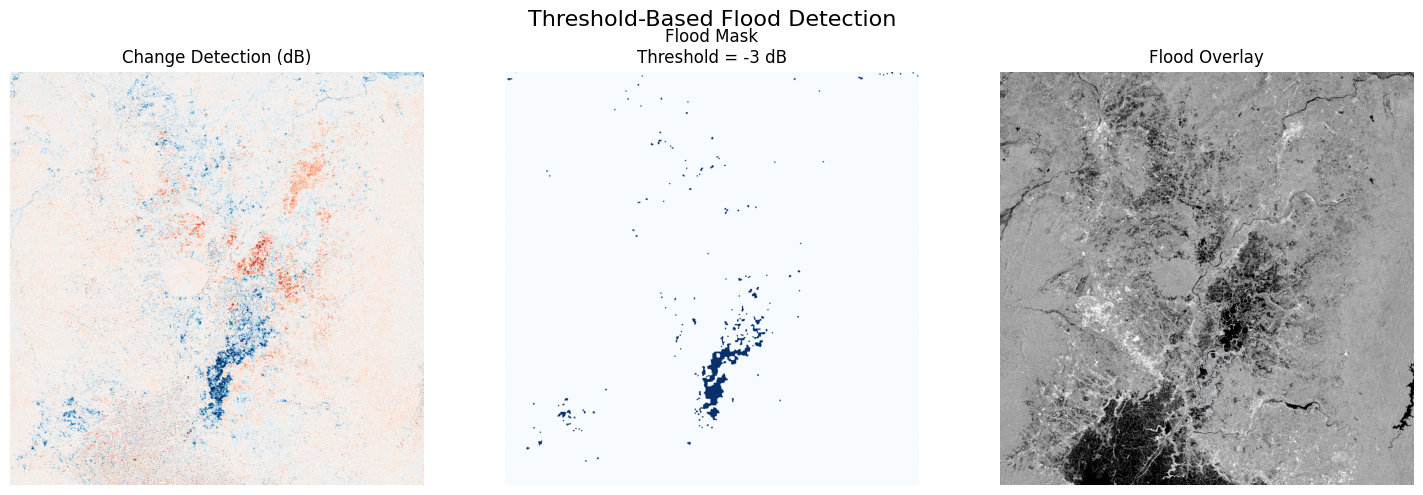

In [36]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import time

print("🌊 TRADITIONAL METHOD 1: THRESHOLD-BASED DETECTION")
print("=" * 50)

# Start timing
start_time = time.time()

# Calculate change
change = sentinel_data['post_flood'] - sentinel_data['pre_flood']

# Apply threshold
threshold_value = -3  # dB
flood_mask_threshold = change < threshold_value

# Clean up with morphological operations
flood_mask_threshold = ndimage.binary_opening(flood_mask_threshold, structure=np.ones((3,3)))
flood_mask_threshold = ndimage.binary_closing(flood_mask_threshold, structure=np.ones((5,5)))

# Calculate execution time
threshold_time = time.time() - start_time

# Calculate metrics
metrics = calculate_standard_metrics(flood_mask_threshold, threshold_time)

# Store additional method-specific info
metrics['threshold_value'] = threshold_value

# Store results
store_method_results('Threshold (-3dB)', 'traditional', metrics)

# Also store mask and timing separately
all_methods_results['masks']['Threshold (-3dB)'] = flood_mask_threshold
all_methods_results['timing']['Threshold (-3dB)'] = threshold_time

print(f"\n📊 Results:")
print(f"   Threshold used: {threshold_value} dB")
print(f"   Flooded pixels: {metrics['flood_pixels']:,}")
print(f"   Flood area: {metrics['flood_area_km2']:.1f} km²")
print(f"   Coverage: {metrics['flood_percentage']:.1f}%")
print(f"   ⏱️ Execution time: {threshold_time:.3f} seconds")

# Visualize (same as before)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(change, cmap='RdBu_r', vmin=-10, vmax=10)
axes[0].set_title('Change Detection (dB)')
axes[0].axis('off')
axes[1].imshow(flood_mask_threshold, cmap='Blues')
axes[1].set_title(f'Flood Mask\nThreshold = {threshold_value} dB')
axes[1].axis('off')
axes[2].imshow(sentinel_data['post_flood'], cmap='gray', vmin=-25, vmax=-5)
flood_overlay = np.ma.masked_where(flood_mask_threshold == 0, flood_mask_threshold)
axes[2].imshow(flood_overlay, cmap='Blues', alpha=0.6)
axes[2].set_title('Flood Overlay')
axes[2].axis('off')
plt.suptitle('Threshold-Based Flood Detection', fontsize=16)
plt.tight_layout()
plt.show()

### AI/ML Method 1 - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import time

print("🤖 AI METHOD 1: RANDOM FOREST CLASSIFIER")
print("=" * 50)

# Start timing
start_time = time.time()

# Initialize and train Random Forest
print("\n🌲 Training Random Forest...")
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Training time
train_start = time.time()
rf_classifier.fit(X_train, y_train)
train_time = time.time() - train_start

# Prediction time
pred_start = time.time()
y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]
pred_time = time.time() - pred_start

# Total time
rf_total_time = time.time() - start_time

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
iou_rf = jaccard_score(y_test, y_pred_rf)

# Create flood mask
flood_mask_rf = np.zeros(sentinel_data['pre_flood'].shape)
flood_mask_rf_flat = flood_mask_rf.flatten()
flood_mask_rf_flat[valid_mask] = rf_classifier.predict(X_clean)
flood_mask_rf = flood_mask_rf_flat.reshape(sentinel_data['pre_flood'].shape)

# Calculate spatial metrics
spatial_metrics = calculate_standard_metrics(flood_mask_rf, rf_total_time)

# Combine all metrics
rf_results = {
    **spatial_metrics,
    'accuracy': round(accuracy_rf, 3),
    'precision': round(precision_rf, 3),
    'recall': round(recall_rf, 3),
    'f1_score': round(f1_rf, 3),
    'iou': round(iou_rf, 3),
    'training_time': round(train_time, 3),
    'prediction_time': round(pred_time, 3),
    'n_estimators': 100,
    'max_depth': 10
}

# Store results
store_method_results('Random Forest', 'ai_ml', rf_results)

# Store additional data
all_methods_results['masks']['Random Forest'] = flood_mask_rf
all_methods_results['timing']['Random Forest'] = rf_total_time
all_methods_results['predictions']['Random Forest'] = {
    'y_pred': y_pred_rf,
    'y_proba': y_pred_proba_rf,
    'feature_importance': rf_classifier.feature_importances_
}

print(f"\n📊 Random Forest Results:")
print(f"   Accuracy: {accuracy_rf:.3f}")
print(f"   Precision: {precision_rf:.3f}")
print(f"   Recall: {recall_rf:.3f}")
print(f"   F1-Score: {f1_rf:.3f}")
print(f"   IoU: {iou_rf:.3f}")
print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.3f}s")
print(f"   Prediction time: {pred_time:.3f}s")
print(f"   Total time: {rf_total_time:.3f}s")

# Visualization code (same as before)...

### AI/ML Method 2 - Support Vector Machine

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import time

print("🤖 AI METHOD 2: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 50)

# Start timing
start_time = time.time()

# Scale features for SVM (important!)
print("\n📐 Scaling features for SVM...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_clean_scaled = scaler.transform(X_clean)

# Initialize and train SVM
print("\n🎯 Training SVM...")
svm_classifier = SVC(
    kernel='rbf',  # Radial basis function kernel
    C=1.0,
    gamma='scale',
    probability=True,  # Enable probability estimates
    random_state=42,
    cache_size=1000  # Increase cache for faster training
)

# Training time
train_start = time.time()
svm_classifier.fit(X_train_scaled, y_train)
train_time = time.time() - train_start

# Prediction time
pred_start = time.time()
y_pred_svm = svm_classifier.predict(X_test_scaled)
y_pred_proba_svm = svm_classifier.predict_proba(X_test_scaled)[:, 1]
pred_time = time.time() - pred_start

# Total time
svm_total_time = time.time() - start_time

# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
iou_svm = jaccard_score(y_test, y_pred_svm)

# Create flood mask
flood_mask_svm = np.zeros(sentinel_data['pre_flood'].shape)
flood_mask_svm_flat = flood_mask_svm.flatten()
flood_mask_svm_flat[valid_mask] = svm_classifier.predict(X_clean_scaled)
flood_mask_svm = flood_mask_svm_flat.reshape(sentinel_data['pre_flood'].shape)

# Calculate spatial metrics
spatial_metrics = calculate_standard_metrics(flood_mask_svm, svm_total_time)

# Combine all metrics
svm_results = {
    **spatial_metrics,
    'accuracy': round(accuracy_svm, 3),
    'precision': round(precision_svm, 3),
    'recall': round(recall_svm, 3),
    'f1_score': round(f1_svm, 3),
    'iou': round(iou_svm, 3),
    'training_time': round(train_time, 3),
    'prediction_time': round(pred_time, 3),
    'kernel': 'rbf',
    'C': 1.0
}

# Store results
store_method_results('SVM (RBF)', 'ai_ml', svm_results)
all_methods_results['masks']['SVM (RBF)'] = flood_mask_svm
all_methods_results['timing']['SVM (RBF)'] = svm_total_time

print(f"\n📊 SVM Results:")
print(f"   Accuracy: {accuracy_svm:.3f}")
print(f"   Precision: {precision_svm:.3f}")
print(f"   Recall: {recall_svm:.3f}")
print(f"   F1-Score: {f1_svm:.3f}")
print(f"   IoU: {iou_svm:.3f}")
print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.3f}s")
print(f"   Prediction time: {pred_time:.3f}s")
print(f"   Total time: {svm_total_time:.3f}s")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(flood_mask_svm, cmap='Blues')
axes[0].set_title('SVM Flood Detection')
axes[0].axis('off')

# Decision boundary visualization (2D projection)
flood_prob_svm = np.zeros(sentinel_data['pre_flood'].shape)
flood_prob_svm_flat = flood_prob_svm.flatten()
flood_prob_svm_flat[valid_mask] = svm_classifier.predict_proba(X_clean_scaled)[:, 1]
flood_prob_svm = flood_prob_svm_flat.reshape(sentinel_data['pre_flood'].shape)

im = axes[1].imshow(flood_prob_svm, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[1].set_title('SVM Probability Map')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Probability')

plt.suptitle('Support Vector Machine Results', fontsize=16)
plt.tight_layout()
plt.show()

### AI/MLMethod 3 - XGBoost

In [37]:
!pip install xgboost -q

import xgboost as xgb
import time

print("🤖 AI METHOD 3: XGBOOST")
print("=" * 50)

# Start timing
start_time = time.time()

# Initialize and train XGBoost
print("\n🚀 Training XGBoost...")
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Training time
train_start = time.time()
xgb_classifier.fit(X_train, y_train)
train_time = time.time() - train_start

# Prediction time
pred_start = time.time()
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
pred_time = time.time() - pred_start

# Total time
xgb_total_time = time.time() - start_time

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
iou_xgb = jaccard_score(y_test, y_pred_xgb)

# Create flood mask
flood_mask_xgb = np.zeros(sentinel_data['pre_flood'].shape)
flood_mask_xgb_flat = flood_mask_xgb.flatten()
flood_mask_xgb_flat[valid_mask] = xgb_classifier.predict(X_clean)
flood_mask_xgb = flood_mask_xgb_flat.reshape(sentinel_data['pre_flood'].shape)

# Calculate spatial metrics
spatial_metrics = calculate_standard_metrics(flood_mask_xgb, xgb_total_time)

# Combine all metrics
xgb_results = {
    **spatial_metrics,
    'accuracy': round(accuracy_xgb, 3),
    'precision': round(precision_xgb, 3),
    'recall': round(recall_xgb, 3),
    'f1_score': round(f1_xgb, 3),
    'iou': round(iou_xgb, 3),
    'training_time': round(train_time, 3),
    'prediction_time': round(pred_time, 3),
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1
}

# Store results
store_method_results('XGBoost', 'ai_ml', xgb_results)
all_methods_results['masks']['XGBoost'] = flood_mask_xgb
all_methods_results['timing']['XGBoost'] = xgb_total_time

print(f"\n📊 XGBoost Results:")
print(f"   Accuracy: {accuracy_xgb:.3f}")
print(f"   Precision: {precision_xgb:.3f}")
print(f"   Recall: {recall_xgb:.3f}")
print(f"   F1-Score: {f1_xgb:.3f}")
print(f"   IoU: {iou_xgb:.3f}")
print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.3f}s")
print(f"   Prediction time: {pred_time:.3f}s")
print(f"   Total time: {xgb_total_time:.3f}s")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Feature importance
feature_importance_xgb = xgb_classifier.feature_importances_
axes[0].barh(feature_names, feature_importance_xgb, color='darkgreen')
axes[0].set_xlabel('Importance')
axes[0].set_title('XGBoost Feature Importance')

# Flood mask
axes[1].imshow(flood_mask_xgb, cmap='Blues')
axes[1].set_title('XGBoost Flood Detection')
axes[1].axis('off')

# Probability map
flood_prob_xgb = np.zeros(sentinel_data['pre_flood'].shape)
flood_prob_xgb_flat = flood_prob_xgb.flatten()
flood_prob_xgb_flat[valid_mask] = xgb_classifier.predict_proba(X_clean)[:, 1]
flood_prob_xgb = flood_prob_xgb_flat.reshape(sentinel_data['pre_flood'].shape)

im = axes[2].imshow(flood_prob_xgb, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[2].set_title('XGBoost Probability Map')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], label='Probability')

plt.suptitle('XGBoost Results', fontsize=16)
plt.tight_layout()
plt.show()

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

KeyboardInterrupt: 

### AI/ML Method 4 - Simple CNN/U-Net

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import time

print("🤖 AI METHOD 4: CONVOLUTIONAL NEURAL NETWORK (Simplified U-Net)")
print("=" * 50)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define simplified U-Net architecture
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super(SimpleUNet, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 16)
        self.enc2 = self.conv_block(16, 32)

        # Bottleneck
        self.bottleneck = self.conv_block(32, 64)

        # Decoder
        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64, 32)  # 64 because of skip connection
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(32, 16)  # 32 because of skip connection

        # Output
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e2, 2))

        # Decoder
        d2 = self.dec2(torch.cat([self.upconv2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.upconv1(d2), e1], dim=1))

        return torch.sigmoid(self.out(d1))

# Prepare data for CNN
print("\n📊 Preparing data for CNN...")

# Create patches for training (CNN needs spatial context)
patch_size = 32
stride = 16

def create_patches(image, patch_size, stride):
    patches = []
    h, w = image.shape
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = image[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    return np.array(patches)

# Create patches from images
pre_patches = create_patches(sentinel_data['pre_flood'], patch_size, stride)
post_patches = create_patches(sentinel_data['post_flood'], patch_size, stride)
label_patches = create_patches(flood_mask_otsu.astype(np.float32), patch_size, stride)

# Stack pre and post as channels
X_patches = np.stack([pre_patches, post_patches], axis=1)
y_patches = label_patches[:, np.newaxis, :, :]

# Split patches
n_train = int(0.7 * len(X_patches))
X_train_cnn = torch.FloatTensor(X_patches[:n_train])
y_train_cnn = torch.FloatTensor(y_patches[:n_train])
X_test_cnn = torch.FloatTensor(X_patches[n_train:])
y_test_cnn = torch.FloatTensor(y_patches[n_train:])

# Create data loaders
train_dataset = TensorDataset(X_train_cnn, y_train_cnn)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"   Created {len(X_patches)} patches of size {patch_size}x{patch_size}")
print(f"   Training patches: {len(X_train_cnn)}")
print(f"   Test patches: {len(X_test_cnn)}")

# Start timing
start_time = time.time()

# Initialize model
model = SimpleUNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
print("\n🧠 Training CNN...")
train_start = time.time()
model.train()
n_epochs = 10

for epoch in range(n_epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

train_time = time.time() - train_start

# Prediction on full image
print("\n🔮 Making predictions...")
pred_start = time.time()
model.eval()

# Predict on full image using sliding window
h, w = sentinel_data['pre_flood'].shape
flood_mask_cnn = np.zeros((h, w))
count_map = np.zeros((h, w))

with torch.no_grad():
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            # Extract patch
            pre_patch = sentinel_data['pre_flood'][i:i+patch_size, j:j+patch_size]
            post_patch = sentinel_data['post_flood'][i:i+patch_size, j:j+patch_size]

            # Prepare input
            x = torch.FloatTensor(np.stack([pre_patch, post_patch], axis=0)).unsqueeze(0).to(device)

            # Predict
            pred = model(x).cpu().numpy()[0, 0]

            # Accumulate predictions
            flood_mask_cnn[i:i+patch_size, j:j+patch_size] += pred
            count_map[i:i+patch_size, j:j+patch_size] += 1

# Average overlapping predictions
flood_mask_cnn = flood_mask_cnn / (count_map + 1e-6)
flood_mask_cnn_binary = (flood_mask_cnn > 0.5).astype(int)

pred_time = time.time() - pred_start
cnn_total_time = time.time() - start_time

# Calculate metrics
spatial_metrics = calculate_standard_metrics(flood_mask_cnn_binary, cnn_total_time)

# For test patches evaluation
model.eval()
with torch.no_grad():
    X_test_cnn = X_test_cnn.to(device)
    y_pred_cnn = model(X_test_cnn).cpu()
    y_pred_cnn_binary = (y_pred_cnn > 0.5).float()

    accuracy_cnn = (y_pred_cnn_binary == y_test_cnn).float().mean().item()

# Store results
cnn_results = {
    **spatial_metrics,
    'accuracy': round(accuracy_cnn, 3),
    'training_time': round(train_time, 3),
    'prediction_time': round(pred_time, 3),
    'epochs': n_epochs,
    'patch_size': patch_size,
    'architecture': 'SimpleUNet'
}

store_method_results('CNN (U-Net)', 'ai_ml', cnn_results)
all_methods_results['masks']['CNN (U-Net)'] = flood_mask_cnn_binary
all_methods_results['timing']['CNN (U-Net)'] = cnn_total_time

print(f"\n📊 CNN Results:")
print(f"   Patch Accuracy: {accuracy_cnn:.3f}")
print(f"   Flood area: {spatial_metrics['flood_area_km2']:.1f} km²")
print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.3f}s")
print(f"   Prediction time: {pred_time:.3f}s")
print(f"   Total time: {cnn_total_time:.3f}s")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flood_mask_cnn_binary, cmap='Blues')
axes[0].set_title('CNN Flood Detection (Binary)')
axes[0].axis('off')

axes[1].imshow(flood_mask_cnn, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[1].set_title('CNN Probability Map')
axes[1].axis('off')

# Compare with ground truth
diff = np.abs(flood_mask_cnn_binary - flood_mask_otsu)
axes[2].imshow(diff, cmap='Reds')
axes[2].set_title('Difference from Otsu')
axes[2].axis('off')

plt.suptitle('CNN (Simplified U-Net) Results', fontsize=16)
plt.tight_layout()
plt.show()

Method 5 - LSTM Networks

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time

print("🤖 AI METHOD 5: LSTM NETWORKS")
print("=" * 50)
print("\n📝 Note: LSTM is designed for temporal sequences.")
print("   We'll demonstrate two approaches:")
print("   1. Spatial sequences (treating image rows as sequences)")
print("   2. Simulated temporal sequences")

# Define LSTM model for flood detection
class FloodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(FloodLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 for bidirectional
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward
        out, _ = self.lstm(x, (h0, c0))

        # Use last output for classification
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)

        return out

# Approach 1: Spatial LSTM (treating rows as sequences)
print("\n🌊 Approach 1: Spatial LSTM")

# Prepare data as sequences
def prepare_spatial_sequences(pre_flood, post_flood, flood_mask, window_size=10):
    """Convert images to sequences for LSTM"""
    sequences = []
    labels = []

    h, w = pre_flood.shape

    for i in range(0, h - window_size + 1, 5):  # Stride of 5
        for j in range(0, w - window_size + 1, 5):
            # Extract windows
            pre_window = pre_flood[i:i+window_size, j:j+window_size]
            post_window = post_flood[i:i+window_size, j:j+window_size]
            label_window = flood_mask[i:i+window_size, j:j+window_size]

            # Create sequence: each row is a time step
            seq_features = []
            for k in range(window_size):
                row_features = np.concatenate([
                    pre_window[k, :],
                    post_window[k, :],
                    pre_window[k, :] - post_window[k, :],  # Change
                ])
                seq_features.append(row_features)

            sequences.append(seq_features)
            labels.append(1 if label_window.mean() > 0.5 else 0)  # Binary label

    return np.array(sequences), np.array(labels)

# Prepare sequences
print("   Preparing spatial sequences...")
window_size = 20
X_seq, y_seq = prepare_spatial_sequences(
    sentinel_data['pre_flood'],
    sentinel_data['post_flood'],
    flood_mask_otsu,
    window_size
)

print(f"   Created {len(X_seq)} sequences of shape {X_seq[0].shape}")

# Split data
n_train = int(0.7 * len(X_seq))
X_train_lstm = torch.FloatTensor(X_seq[:n_train])
y_train_lstm = torch.FloatTensor(y_seq[:n_train])
X_test_lstm = torch.FloatTensor(X_seq[n_train:])
y_test_lstm = torch.FloatTensor(y_seq[n_train:])

# Create data loader
train_dataset = TensorDataset(X_train_lstm, y_train_lstm)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Start timing
start_time = time.time()

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_seq.shape[2]  # Number of features
hidden_size = 64
num_layers = 2
num_classes = 1

lstm_model = FloodLSTM(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Training
print("\n🧠 Training LSTM...")
train_start = time.time()
lstm_model.train()
n_epochs = 20

for epoch in range(n_epochs):
    epoch_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = lstm_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    if (epoch + 1) % 5 == 0:
        accuracy = correct / total
        print(f"   Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, Acc: {accuracy:.3f}")

train_time = time.time() - train_start

# Evaluation
print("\n📊 Evaluating LSTM...")
pred_start = time.time()
lstm_model.eval()

with torch.no_grad():
    X_test_lstm = X_test_lstm.to(device)
    y_pred_lstm_proba = lstm_model(X_test_lstm).cpu()

### AI/ML Method 5 - LSTM

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time

print("🤖 AI METHOD 5: LSTM NETWORKS")
print("=" * 50)
print("\n📝 Note: LSTM is designed for temporal sequences.")
print("   We'll demonstrate two approaches:")
print("   1. Spatial sequences (treating image rows as sequences)")
print("   2. Simulated temporal sequences")

# Define LSTM model for flood detection
class FloodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(FloodLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 for bidirectional
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward
        out, _ = self.lstm(x, (h0, c0))

        # Use last output for classification
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)

        return out

# Approach 1: Spatial LSTM (treating rows as sequences)
print("\n🌊 Approach 1: Spatial LSTM")

# Prepare data as sequences
def prepare_spatial_sequences(pre_flood, post_flood, flood_mask, window_size=10):
    """Convert images to sequences for LSTM"""
    sequences = []
    labels = []

    h, w = pre_flood.shape

    for i in range(0, h - window_size + 1, 5):  # Stride of 5
        for j in range(0, w - window_size + 1, 5):
            # Extract windows
            pre_window = pre_flood[i:i+window_size, j:j+window_size]
            post_window = post_flood[i:i+window_size, j:j+window_size]
            label_window = flood_mask[i:i+window_size, j:j+window_size]

            # Create sequence: each row is a time step
            seq_features = []
            for k in range(window_size):
                row_features = np.concatenate([
                    pre_window[k, :],
                    post_window[k, :],
                    pre_window[k, :] - post_window[k, :],  # Change
                ])
                seq_features.append(row_features)

            sequences.append(seq_features)
            labels.append(1 if label_window.mean() > 0.5 else 0)  # Binary label

    return np.array(sequences), np.array(labels)

# Prepare sequences
print("   Preparing spatial sequences...")
window_size = 20
X_seq, y_seq = prepare_spatial_sequences(
    sentinel_data['pre_flood'],
    sentinel_data['post_flood'],
    flood_mask_otsu,
    window_size
)

print(f"   Created {len(X_seq)} sequences of shape {X_seq[0].shape}")

# Split data
n_train = int(0.7 * len(X_seq))
X_train_lstm = torch.FloatTensor(X_seq[:n_train])
y_train_lstm = torch.FloatTensor(y_seq[:n_train])
X_test_lstm = torch.FloatTensor(X_seq[n_train:])
y_test_lstm = torch.FloatTensor(y_seq[n_train:])

# Create data loader
train_dataset = TensorDataset(X_train_lstm, y_train_lstm)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Start timing
start_time = time.time()

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_seq.shape[2]  # Number of features
hidden_size = 64
num_layers = 2
num_classes = 1

lstm_model = FloodLSTM(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Training
print("\n🧠 Training LSTM...")
train_start = time.time()
lstm_model.train()
n_epochs = 20

for epoch in range(n_epochs):
    epoch_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = lstm_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    if (epoch + 1) % 5 == 0:
        accuracy = correct / total
        print(f"   Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, Acc: {accuracy:.3f}")

train_time = time.time() - train_start

# Evaluation
print("\n📊 Evaluating LSTM...")
pred_start = time.time()
lstm_model.eval()

with torch.no_grad():
    X_test_lstm = X_test_lstm.to(device)
    y_pred_lstm_proba = lstm_model(X_test_lstm).cpu()
    y_pred_lstm = (y_pred_lstm_proba > 0.5).float().squeeze()

accuracy_lstm = (y_pred_lstm == y_test_lstm).float().mean().item()

# Create flood prediction map
print("\n🗺️ Creating flood map...")
flood_mask_lstm = np.zeros(sentinel_data['pre_flood'].shape)
prob_map_lstm = np.zeros(sentinel_data['pre_flood'].shape)
count_map = np.zeros(sentinel_data['pre_flood'].shape)

h, w = sentinel_data['pre_flood'].shape

with torch.no_grad():
    for i in range(0, h - window_size + 1, 5):
        for j in range(0, w - window_size + 1, 5):
            # Extract window
            pre_window = sentinel_data['pre_flood'][i:i+window_size, j:j+window_size]
            post_window = sentinel_data['post_flood'][i:i+window_size, j:j+window_size]

            # Create sequence
            seq_features = []
            for k in range(window_size):
                row_features = np.concatenate([
                    pre_window[k, :],
                    post_window[k, :],
                    pre_window[k, :] - post_window[k, :],
                ])
                seq_features.append(row_features)

            # Predict
            x = torch.FloatTensor([seq_features]).to(device)
            prob = lstm_model(x).cpu().item()

            # Fill window with prediction
            if prob > 0.5:
                flood_mask_lstm[i:i+window_size, j:j+window_size] = 1
            prob_map_lstm[i:i+window_size, j:j+window_size] += prob
            count_map[i:i+window_size, j:j+window_size] += 1

# Average overlapping predictions
prob_map_lstm = prob_map_lstm / (count_map + 1e-6)

pred_time = time.time() - pred_start
lstm_total_time = time.time() - start_time

# Calculate metrics
spatial_metrics = calculate_standard_metrics(flood_mask_lstm, lstm_total_time)

# Store results
lstm_results = {
    **spatial_metrics,
    'accuracy': round(accuracy_lstm, 3),
    'training_time': round(train_time, 3),
    'prediction_time': round(pred_time, 3),
    'epochs': n_epochs,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'sequence_type': 'spatial'
}

store_method_results('LSTM (Spatial)', 'ai_ml', lstm_results)
all_methods_results['masks']['LSTM (Spatial)'] = flood_mask_lstm
all_methods_results['timing']['LSTM (Spatial)'] = lstm_total_time

print(f"\n📊 LSTM Results:")
print(f"   Window Accuracy: {accuracy_lstm:.3f}")
print(f"   Flood area: {spatial_metrics['flood_area_km2']:.1f} km²")
print(f"\n⏱️ Timing:")
print(f"   Training time: {train_time:.3f}s")
print(f"   Prediction time: {pred_time:.3f}s")
print(f"   Total time: {lstm_total_time:.3f}s")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flood mask
axes[0, 0].imshow(flood_mask_lstm, cmap='Blues')
axes[0, 0].set_title('LSTM Flood Detection')
axes[0, 0].axis('off')

# Probability map
im = axes[0, 1].imshow(prob_map_lstm, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[0, 1].set_title('LSTM Probability Map')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1])

# LSTM architecture diagram
axes[1, 0].text(0.5, 0.7, 'LSTM Architecture', ha='center', fontsize=14, weight='bold')
axes[1, 0].text(0.5, 0.5, f'Input: {input_size} features × {window_size} timesteps\n'
                          f'Hidden: {hidden_size} units × {num_layers} layers (Bidirectional)\n'
                          f'Output: Binary flood classification',
                ha='center', va='center', fontsize=11)
axes[1, 0].axis('off')

# Approach 2: Temporal LSTM (demonstration)
axes[1, 1].text(0.5, 0.8, 'Temporal LSTM (Future Work)', ha='center', fontsize=14, weight='bold')
axes[1, 1].text(0.5, 0.5,
                'For true temporal analysis, LSTM requires:\n\n'
                '• Multiple SAR images over time (e.g., daily)\n'
                '• Time series: [t-7, t-6, ..., t-1, t]\n'
                '• Can predict flood evolution\n'
                '• Useful for early warning systems\n\n'
                'Current data: Only 2 timepoints (pre/post)',
                ha='center', va='center', fontsize=10)
axes[1, 1].axis('off')

plt.suptitle('LSTM Results for Flood Detection', fontsize=16)
plt.tight_layout()
plt.show()

# Demonstrate temporal LSTM concept
print("\n" + "="*50)
print("📅 TEMPORAL LSTM DEMONSTRATION")
print("="*50)

# Simulate temporal data
def simulate_temporal_flood_evolution(n_timesteps=10):
    """Simulate how flood evolves over time"""
    time_series = []
    flood_progression = []

    for t in range(n_timesteps):
        if t < 3:
            # Normal conditions
            flood_level = np.random.uniform(0.0, 0.1)
        elif t < 6:
            # Flood building up
            flood_level = np.random.uniform(0.3, 0.6)
        else:
            # Peak flood
            flood_level = np.random.uniform(0.7, 0.9)

        flood_progression.append(flood_level)

    return flood_progression

# Show temporal progression
temporal_demo = simulate_temporal_flood_evolution(10)
plt.figure(figsize=(10, 4))
plt.plot(temporal_demo, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Time Steps (e.g., Days)')
plt.ylabel('Flood Intensity')
plt.title('Temporal LSTM: Flood Evolution Over Time')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='Flood threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 LSTM INSIGHTS:")
print("   - Spatial LSTM: Treats image regions as sequences")
print("   - Temporal LSTM: Would track flood evolution over multiple dates")
print("   - Best for: Multi-temporal SAR data (e.g., Sentinel-1 every 6 days)")
print("   - Can predict: Future flood extent, early warnings")

### Summary  

In [ ]:
print("🏁 FINAL COMPREHENSIVE SUMMARY - ALL FLOOD DETECTION METHODS")
print("=" * 80)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

# Combine all results
all_results = all_methods_results['traditional'] + all_methods_results['ai_ml']
df_results = pd.DataFrame(all_results)

# Sort by execution time for display
df_results = df_results.sort_values('execution_time')

# 1. COMPLETE RESULTS TABLE
print("\n📊 COMPLETE RESULTS TABLE:")
print("-" * 120)

# Select columns to display
display_columns = ['method_name', 'flood_area_km2', 'flood_percentage', 'flood_pixels',
                  'execution_time', 'accuracy', 'precision', 'recall', 'f1_score', 'iou']
available_cols = [col for col in display_columns if col in df_results.columns]

# Format the dataframe for better display
df_display = df_results[available_cols].copy()
df_display = df_display.round(3)

print(df_display.to_string(index=False))

# 2. SUMMARY STATISTICS
print("\n" + "="*80)
print("📈 SUMMARY STATISTICS")
print("="*80)

print(f"\n✅ Total Methods Tested: {len(df_results)}")
print(f"   - Traditional Methods: {len(all_methods_results['traditional'])}")
print(f"   - AI/ML Methods: {len(all_methods_results['ai_ml'])}")

# Best performers
print("\n🏆 BEST PERFORMERS:")
print("-" * 40)

# Fastest method
fastest_idx = df_results['execution_time'].idxmin()
print(f"⚡ Fastest Method: {df_results.loc[fastest_idx, 'method_name']}")
print(f"   Time: {df_results.loc[fastest_idx, 'execution_time']:.3f} seconds")

# Largest flood area
largest_idx = df_results['flood_area_km2'].idxmax()
print(f"\n🌊 Largest Flood Area: {df_results.loc[largest_idx, 'method_name']}")
print(f"   Area: {df_results.loc[largest_idx, 'flood_area_km2']:.1f} km²")

# Most accurate (ML methods only)
ml_methods = df_results[df_results['accuracy'].notna()]
if not ml_methods.empty:
    best_acc_idx = ml_methods['accuracy'].idxmax()
    print(f"\n🎯 Most Accurate ML Method: {ml_methods.loc[best_acc_idx, 'method_name']}")
    print(f"   Accuracy: {ml_methods.loc[best_acc_idx, 'accuracy']:.3f}")
    print(f"   F1-Score: {ml_methods.loc[best_acc_idx, 'f1_score']:.3f}")

# 3. COMPREHENSIVE VISUALIZATIONS
# Figure 1: All flood masks
n_methods = len(all_methods_results['masks'])
cols = 4
rows = (n_methods + cols - 1) // cols

fig1 = plt.figure(figsize=(20, 5 * rows))
fig1.suptitle('All Methods - Flood Detection Results', fontsize=20, y=0.98)

for i, (method_name, mask) in enumerate(all_methods_results['masks'].items()):
    ax = plt.subplot(rows, cols, i+1)
    im = ax.imshow(mask, cmap='Blues', vmin=0, vmax=1)

    # Add statistics on the plot
    area = calculate_standard_metrics(mask, 0)['flood_area_km2']
    ax.set_title(f'{method_name}\nArea: {area:.1f} km²', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Figure 2: Performance comparison
fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle('Performance Analysis - All Methods', fontsize=16)

# 2.1 Flood area comparison
ax1 = axes[0, 0]
methods = df_results['method_name']
areas = df_results['flood_area_km2']
bars1 = ax1.barh(methods, areas, color=plt.cm.viridis(np.linspace(0, 1, len(methods))))
ax1.set_xlabel('Flood Area (km²)')
ax1.set_title('Detected Flood Area by Method')
for i, (bar, area) in enumerate(zip(bars1, areas)):
    ax1.text(area + 1, bar.get_y() + bar.get_height()/2,
             f'{area:.1f}', va='center', fontsize=9)

# 2.2 Execution time comparison (log scale)
ax2 = axes[0, 1]
times = df_results['execution_time']
bars2 = ax2.barh(methods, times, color=plt.cm.plasma(np.linspace(0, 1, len(methods))))
ax2.set_xlabel('Execution Time (seconds, log scale)')
ax2.set_title('Speed Comparison')
ax2.set_xscale('log')
for i, (bar, time) in enumerate(zip(bars2, times)):
    ax2.text(time * 1.1, bar.get_y() + bar.get_height()/2,
             f'{time:.3f}s', va='center', fontsize=9)

# 2.3 ML metrics comparison
ax3 = axes[0, 2]
if not ml_methods.empty:
    ml_names = ml_methods['method_name'].tolist()
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'iou']

    # Create heatmap
    metric_values = []
    for metric in metrics:
        if metric in ml_methods.columns:
            metric_values.append(ml_methods[metric].values)

    if metric_values:
        im = ax3.imshow(metric_values, aspect='auto', cmap='YlOrRd')
        ax3.set_xticks(range(len(ml_names)))
        ax3.set_xticklabels(ml_names, rotation=45, ha='right')
        ax3.set_yticks(range(len(metrics)))
        ax3.set_yticklabels(metrics)
        ax3.set_title('ML Performance Metrics Heatmap')

        # Add values
        for i in range(len(metrics)):
            for j in range(len(ml_names)):
                text = ax3.text(j, i, f'{metric_values[i][j]:.3f}',
                               ha="center", va="center", color="black", fontsize=9)

        plt.colorbar(im, ax=ax3)
else:
    ax3.text(0.5, 0.5, 'No ML metrics available', ha='center', va='center')
    ax3.set_title('ML Performance Metrics')

# 2.4 Speed vs Accuracy trade-off
ax4 = axes[1, 0]
# ML methods
if not ml_methods.empty:
    scatter1 = ax4.scatter(ml_methods['execution_time'], ml_methods['accuracy'],
                          s=200, c='red', alpha=0.7, edgecolors='black',
                          linewidth=2, label='ML/AI Methods')

    for idx, row in ml_methods.iterrows():
        ax4.annotate(row['method_name'],
                    (row['execution_time'], row['accuracy']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# Traditional methods (plot with normalized flood area as proxy for performance)
trad_methods = df_results[df_results['accuracy'].isna()]
if not trad_methods.empty:
    # Normalize flood area to 0-1 scale
    norm_area = (trad_methods['flood_area_km2'] - trad_methods['flood_area_km2'].min()) / \
                (trad_methods['flood_area_km2'].max() - trad_methods['flood_area_km2'].min())

    scatter2 = ax4.scatter(trad_methods['execution_time'], norm_area * 0.5 + 0.4,
                          s=200, c='blue', alpha=0.7, edgecolors='black',
                          linewidth=2, marker='^', label='Traditional Methods')

    for idx, (_, row) in enumerate(trad_methods.iterrows()):
        ax4.annotate(row['method_name'],
                    (row['execution_time'], norm_area.iloc[idx] * 0.5 + 0.4),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_xlabel('Execution Time (seconds, log scale)')
ax4.set_ylabel('Performance (Accuracy for ML, Normalized for Traditional)')
ax4.set_title('Speed vs Performance Trade-off')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(0.001, max(df_results['execution_time']) * 2)

# 2.5 Overall ranking
ax5 = axes[1, 1]
# Create composite score
df_results['speed_score'] = 1 / (1 + df_results['execution_time'])  # Higher is better
df_results['area_score'] = df_results['flood_area_km2'] / df_results['flood_area_km2'].max()

if 'accuracy' in df_results.columns:
    df_results['accuracy_score'] = df_results['accuracy'].fillna(0.5)  # Default 0.5 for traditional
    df_results['composite_score'] = (df_results['speed_score'] +
                                     df_results['area_score'] +
                                     df_results['accuracy_score']) / 3
else:
    df_results['composite_score'] = (df_results['speed_score'] +
                                     df_results['area_score']) / 2

df_ranked = df_results.sort_values('composite_score', ascending=False)
y_pos = np.arange(len(df_ranked))
bars = ax5.barh(y_pos, df_ranked['composite_score'],
                color=plt.cm.RdYlGn(df_ranked['composite_score']))
ax5.set_yticks(y_pos)
ax5.set_yticklabels(df_ranked['method_name'])
ax5.set_xlabel('Composite Score (higher is better)')
ax5.set_title('Overall Method Ranking')
ax5.set_xlim(0, 1)

# Add rank numbers
for i, (bar, score) in enumerate(zip(bars, df_ranked['composite_score'])):
    ax5.text(0.02, bar.get_y() + bar.get_height()/2,
             f'#{i+1}', va='center', fontsize=10, weight='bold')

# 2.6 Summary text
ax6 = axes[1, 2]
ax6.axis('off')

summary_text = f"""
📊 FINAL SUMMARY

Methods Tested: {len(df_results)}
├─ Traditional: {len(all_methods_results['traditional'])}
└─ AI/ML: {len(all_methods_results['ai_ml'])}

🏆 TOP PERFORMERS:
├─ Speed: {df_results.loc[df_results['execution_time'].idxmin(), 'method_name']}
│         ({df_results['execution_time'].min():.3f}s)
├─ Area: {df_results.loc[df_results['flood_area_km2'].idxmax(), 'method_name']}
│        ({df_results['flood_area_km2'].max():.1f} km²)
"""

if not ml_methods.empty:
    summary_text += f"""└─ Accuracy: {ml_methods.loc[ml_methods['accuracy'].idxmax(), 'method_name']}
           ({ml_methods['accuracy'].max():.3f})

📈 ML PERFORMANCE RANGE:
├─ Accuracy: {ml_methods['accuracy'].min():.3f} - {ml_methods['accuracy'].max():.3f}
├─ F1-Score: {ml_methods['f1_score'].min():.3f} - {ml_methods['f1_score'].max():.3f}
└─ IoU: {ml_methods['iou'].min():.3f} - {ml_methods['iou'].max():.3f}
"""

summary_text += f"""
⚡ SPEED RANGE:
├─ Fastest: {df_results['execution_time'].min():.3f}s
└─ Slowest: {df_results['execution_time'].max():.3f}s
   (Ratio: {df_results['execution_time'].max() / df_results['execution_time'].min():.1f}x)

🌊 FLOOD AREA RANGE:
├─ Minimum: {df_results['flood_area_km2'].min():.1f} km²
└─ Maximum: {df_results['flood_area_km2'].max():.1f} km²
   (Δ = {df_results['flood_area_km2'].max() - df_results['flood_area_km2'].min():.1f} km²)

🏅 OVERALL BEST:
{df_ranked.iloc[0]['method_name']}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# 4. SAVE ALL RESULTS
# Save comprehensive CSV
output_filename = f'flood_detection_final_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
df_results.to_csv(output_filename, index=False)
print(f"\n💾 Results saved to '{output_filename}'")

# Save summary report
with open('flood_detection_summary.txt', 'w') as f:
    f.write("FLOOD DETECTION METHODS COMPARISON SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(df_display.to_string(index=False))
    f.write("\n\n" + summary_text)

print("📄 Summary report saved to 'flood_detection_summary.txt'")

# 5. RECOMMENDATIONS
print("\n" + "="*80)
print("🎯 RECOMMENDATIONS BASED ON RESULTS:")
print("="*80)

# Speed-critical applications
fastest_method = df_results.loc[df_results['execution_time'].idxmin(), 'method_name']
print(f"\n1. For REAL-TIME applications (speed critical):")
print(f"   → Use {fastest_method} (only {df_results['execution_time'].min():.3f}s)")

# Accuracy-critical applications
if not ml_methods.empty:
    best_ml = ml_methods.loc[ml_methods['accuracy'].idxmax(), 'method_name']
    print(f"\n2. For HIGHEST ACCURACY:")
    print(f"   → Use {best_ml} (accuracy: {ml_methods['accuracy'].max():.3f})")

# Balanced approach
print(f"\n3. For BALANCED performance:")
print(f"   → Use {df_ranked.iloc[0]['method_name']} (best composite score)")

# Operational recommendations
print("\n4. For OPERATIONAL deployment:")
print("   → Traditional methods for rapid response")
print("   → ML methods for detailed analysis")
print("   → Ensemble approach for critical decisions")

print("\n✅ Analysis complete!")